In [1]:
import os
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import numpy as np

sys.path.append('..')
from src.evaluate import make_confusion_matrix, make_roc, make_pr
from src.preprocess import preprocess_data
from sklearn.metrics import classification_report
from sklearn.model_selection import TunedThresholdClassifierCV

figures_dir = '../figures' 

In [2]:
_, X_test, _, y_test, preprocessor = preprocess_data(df_filepath='../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

rf = joblib.load('../models/random_forest.joblib')
log = joblib.load('../models/logisitic_regression.joblib')
svc = joblib.load('../models/svm_rbf.joblib')

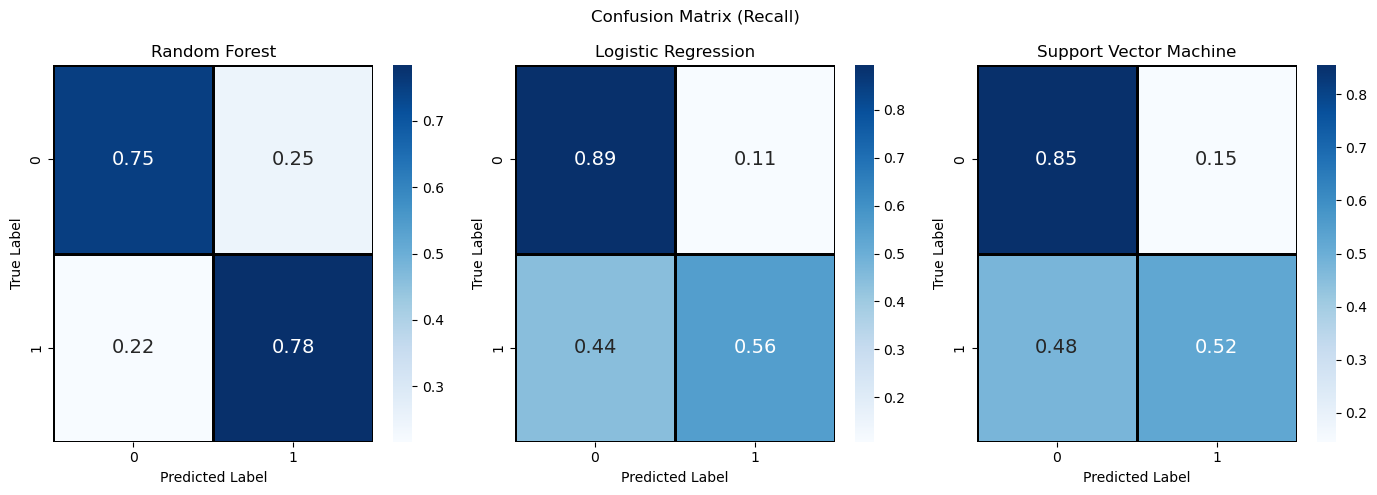

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(14,5))
make_confusion_matrix(y_test, rf.predict(X_test), model_name='Random Forest', by='true', ax=ax[0] )
make_confusion_matrix(y_test, log.predict(X_test), model_name='Logistic Regression', by='true', ax=ax[1])
make_confusion_matrix(y_test, svc.predict(X_test), model_name='Support Vector Machine', by='true', ax=ax[2])
plt.suptitle('Confusion Matrix (Recall)')
plt.tight_layout()
output_path = os.path.join(figures_dir, 'models_confusion_matrix.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

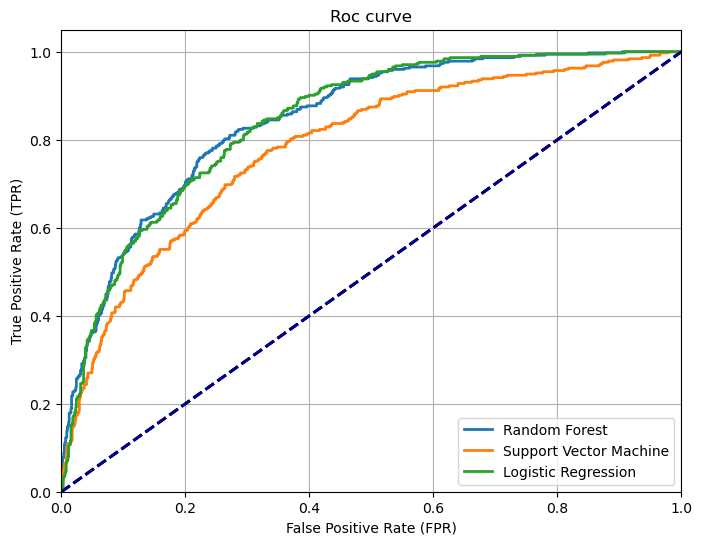

In [4]:
rf_scores = rf.predict_proba(X_test)[:, 1]
svc_scores = svc.predict_proba(X_test)[:, 1]
log_scores = log.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8,6))
make_roc(y_true=y_test, y_proba=rf_scores, model_name='Random Forest')
make_roc(y_true=y_test, y_proba=svc_scores, model_name='Support Vector Machine')
make_roc(y_true=y_test, y_proba=log_scores, model_name='Logistic Regression')
output_path = os.path.join(figures_dir, 'models_roc_curve.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.title('Roc curve')
plt.show()

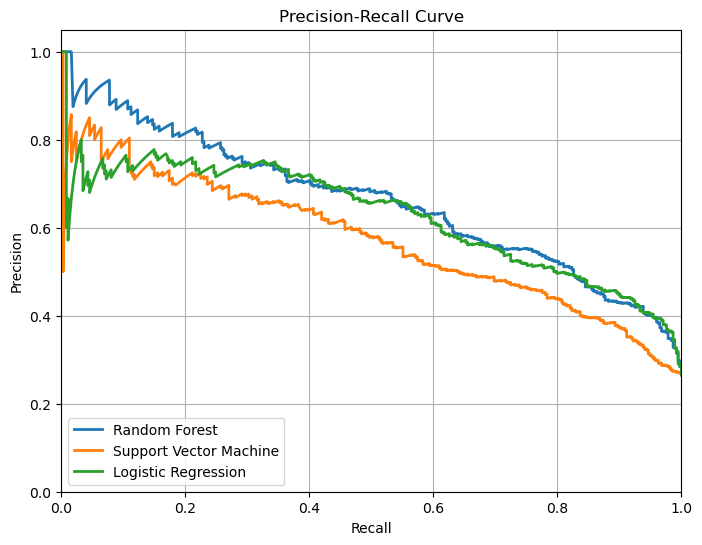

In [5]:
plt.figure(figsize=(8,6))
make_pr(y_true=y_test, y_proba=rf_scores, model_name='Random Forest')
make_pr(y_true=y_test, y_proba=svc_scores, model_name='Support Vector Machine')
make_pr(y_true=y_test, y_proba=log_scores, model_name='Logistic Regression')
output_path = os.path.join(figures_dir, 'models_pr_curve.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

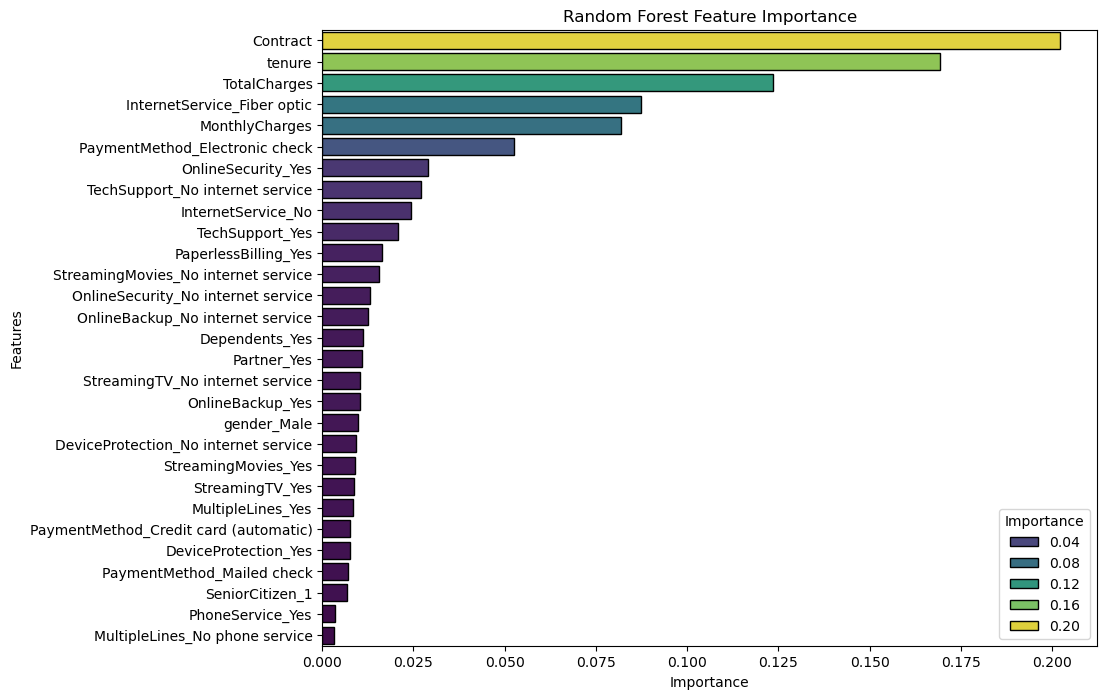

In [6]:
rf.named_steps['preprocessing'].verbose_feature_names_out = False
feature_impotance_rf = rf.named_steps['model'].feature_importances_
features = rf.named_steps['preprocessing'].get_feature_names_out()
feature_df = pd.DataFrame({'Features': features, 
                           'Importance': feature_impotance_rf
                          }).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,8))
sns.barplot(
    data=feature_df,
    y='Features', 
    x='Importance', 
    orient='h',
    hue='Importance', 
    palette='viridis', 
    edgecolor='k'
)
plt.title('Random Forest Feature Importance')
output_path = os.path.join(figures_dir, 'rf_feature_importances.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

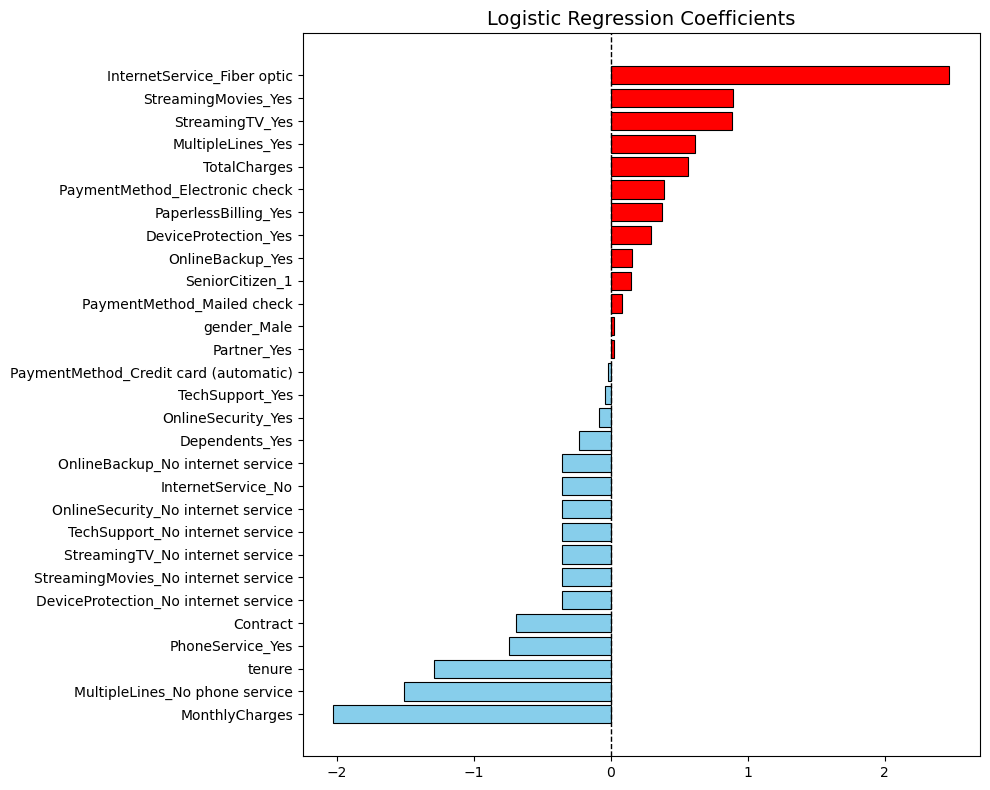

In [7]:
coefficients = log.named_steps['model'].coef_[0]
coef_df = (
    pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
    .sort_values(by='Coefficient', ascending=True)
    .reset_index(drop=True)
)

colors = ['red' if c > 0 else 'skyblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 8))
plt.barh(
    y=coef_df['Feature'],
    width=coef_df['Coefficient'],
    color=colors,
    edgecolor='k',
    linewidth=0.8,
)

plt.title('Logistic Regression Coefficients', fontsize=14)
plt.axvline(0, color='k', linestyle='--', linewidth=1)
output_path = os.path.join(figures_dir, 'logistic_regression_coeffecients.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [22]:
explainer = shap.TreeExplainer(rf.named_steps['model'])
X_test_transformed = preprocessor.transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()
X_test_df = pd.DataFrame(data=X_test_transformed, columns=features)

shap_values = explainer(X_test_df)

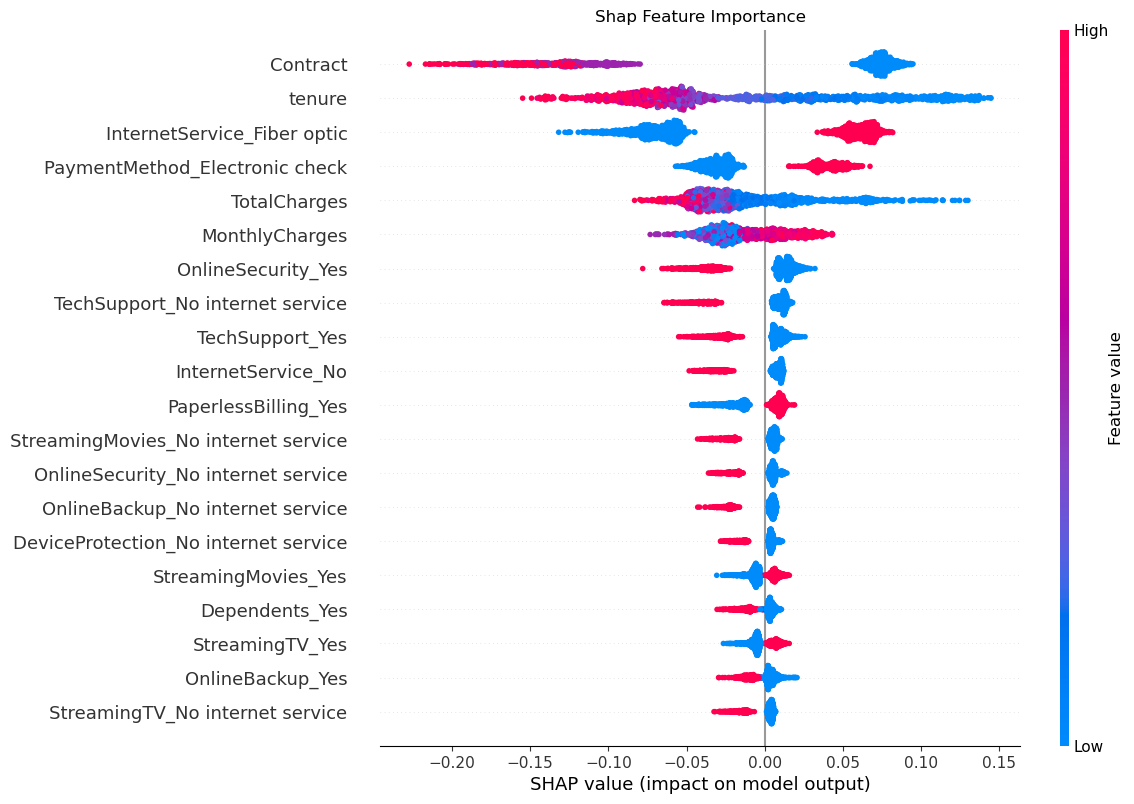

In [65]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_df,
    plot_size=(12, 8),
    show=False,
)
plt.title('Shap Feature Importance')
output_path = os.path.join(figures_dir, 'shap_values.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

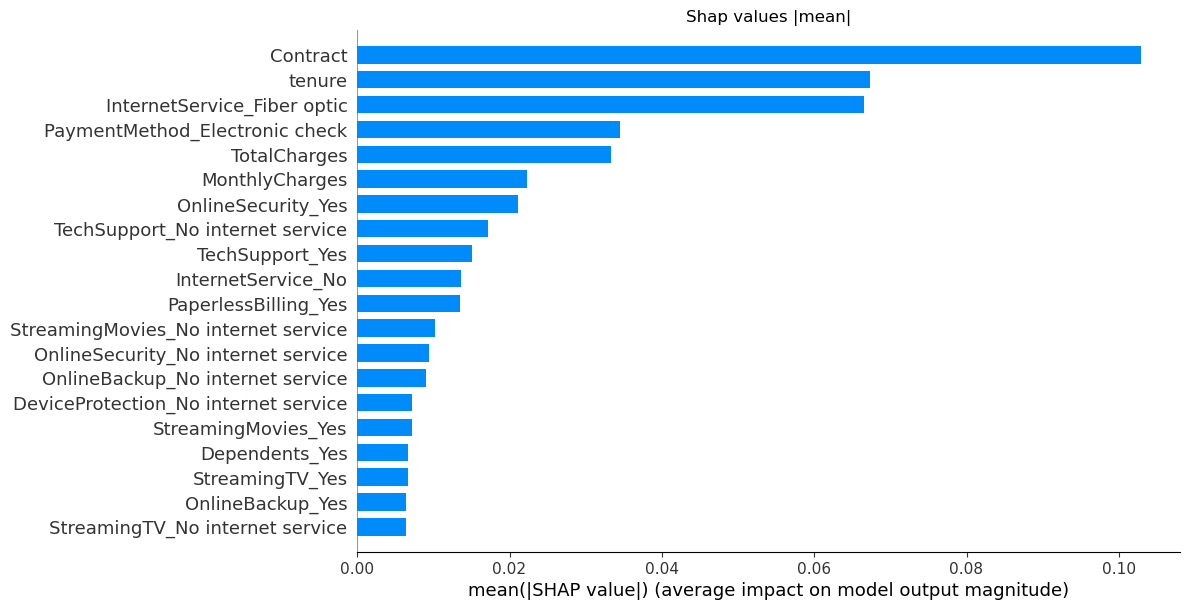

In [42]:
shap.summary_plot(
    shap_values[:, :, 1], X_test_df, plot_type='bar', show=False, plot_size=(12,6)
)
plt.title('Shap values |mean|')
output_path = os.path.join(figures_dir, 'shap_values_bar.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

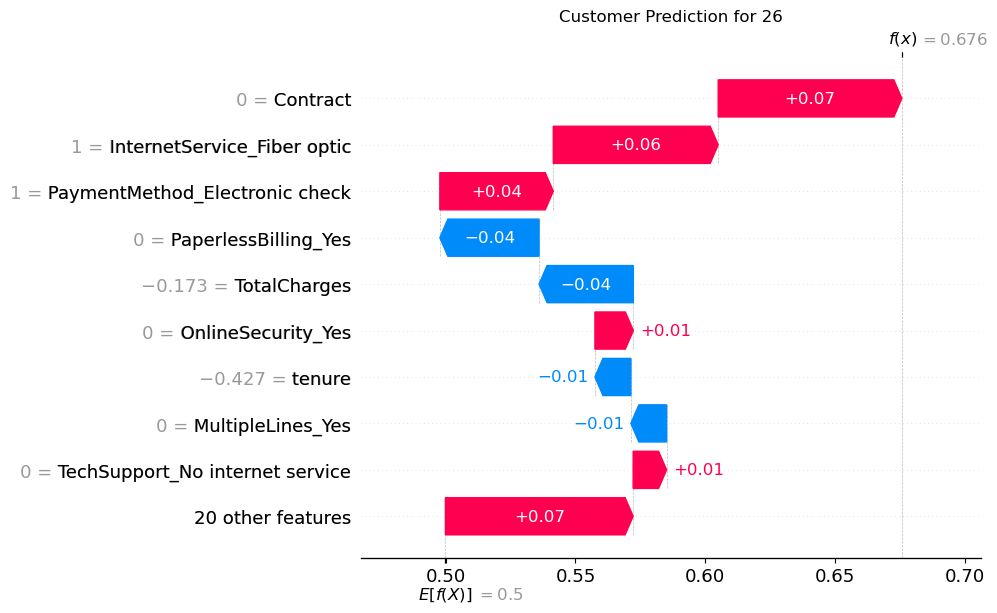

In [66]:
shap.plots.waterfall(shap_values[26, :, 1], show=False)
plt.title('Customer Prediction for 26')
output_path = os.path.join(figures_dir, 'customer_26.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()